# SiPM Double-Coincidence Analysis

This notebook is the editable version of:

- `analysis/dilution_detector/count_sipm_double_coincidences.py`
- `analysis/dilution_detector/plot_double_coincidence_threshold_scan.py`

Run the cells from top to bottom. The main places to edit are the settings cells for the hit files/run directory, SiPM thresholds, optional PDE weighting, and plot options.

In [1]:
from __future__ import annotations

import csv
import glob
import itertools
import json
import math
import os
from collections import defaultdict
from pathlib import Path
from pprint import pprint


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in (start, *start.parents):
        if (path / "analysis" / "dilution_detector").is_dir():
            return path
    raise FileNotFoundError("Could not find the cosmic-geant project root from the current notebook directory")


PROJECT_ROOT = find_project_root()
ANALYSIS_DIR = PROJECT_ROOT / "analysis" / "dilution_detector"
RESULTS_DIR = ANALYSIS_DIR / "results"

MPLCONFIGDIR = ANALYSIS_DIR / ".mplconfig"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))
os.environ.setdefault("XDG_CACHE_HOME", str(MPLCONFIGDIR / "cache"))

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None
    print("matplotlib is not installed in this Python environment; counting cells will still work, but plotting needs matplotlib.")

PROJECT_ROOT

PosixPath('/Users/matildalawton/cosmic-geant')

## Counting Settings

Edit this cell before running the count. `RUN_INPUTS` can contain hit CSV files, glob patterns, build output folders, or archived run directories.

In [ ]:
RUN_INPUTS = [
    "/Users/matildalawton/cosmic-geant/analysis/dilution_detector/results/output",
]
#testing on the 10 M run while longer run is running -> dont forget to delete this folder from here! 

# RUN_INPUTS = [
#     "runs/stage_fridge_clock_above_20cm_cry_10M_20260724_152447",
# ]

SIPM_COPIES = [0, 1]
MIN_PHOTONS_PER_SIPM = 1
background = True #was background included in the simulation 

# Use these two together if you want an efficiency-scaled incident photon threshold.
SIPM_EFFICIENCY = None  # example: 0.40
MIN_DETECTED_PHOTONS_PER_SIPM = None  # example: 80

# Use one row per EventID/TrackID/SiPM copy. Usually False for the current sensitive detector behavior.
UNIQUE_TRACKS = False

# Set PDE_CSV to the digitized curve to use wavelength-dependent detected-photoelectron weights.
#PDE_CSV = None
PDE_CSV = ANALYSIS_DIR / "pde_digitization" / "sipm_pde_digitized.csv"
PDE_COLUMN = "pde_5v_percent"
WEIGHTED_COLUMN_SUFFIX = "pde_weighted_detected_photons"

WRITE_COUNT_OUTPUTS = True
COUNT_OUTPUT_CSV = RESULTS_DIR / "notebook_sipm_counts_by_event.csv"
DOUBLE_EVENTS_OUTPUT_CSV = RESULTS_DIR / "notebook_double_events.csv"
GAMMA_OUTPUT_CSV = RESULTS_DIR / "notebook_gamma_hits.csv"  
GAMMA_SCINTILLATOR_OUTPUT_CSV = RESULTS_DIR / "notebook_gamma_scintillator_hits.csv"
ACCIDENTAL_EVENT_WINDOW = 3
ACCIDENTAL_OUTPUT_CSV = RESULTS_DIR / "notebook_accidental_pairs.csv"
SUMMARY_JSON = RESULTS_DIR / "notebook_summary.json"

## Counting Helpers

These functions are adapted from `count_sipm_double_coincidences.py`.

In [3]:
DEFAULT_COLUMNS = [
    "EventID",
    "TrackID",
    "Particle",
    "EnergyDeposited",
    "XPosition",
    "YPosition",
    "ZPosition",
    "LocalTime",
    "Volume",
    "Copynumber",
    "InitialEnergy",
    "OriginVolume",
    "ParentID",
    "ProcessName",
    "StepID",
]


def resolve_project_path(path: str | Path) -> Path:
    path = Path(path).expanduser()
    return path if path.is_absolute() else PROJECT_ROOT / path


def effective_photon_threshold(
    min_photons_per_sipm: int,
    sipm_efficiency: float | None,
    min_detected_photons_per_sipm: int | None,
) -> tuple[int, dict[str, object]]:
    if min_detected_photons_per_sipm is None:
        return min_photons_per_sipm, {
            "threshold_mode": "recorded_photons",
            "sipm_efficiency": None,
            "min_detected_photons_per_sipm": None,
            "effective_min_recorded_photons_per_sipm": min_photons_per_sipm,
        }

    if sipm_efficiency is None:
        raise ValueError("MIN_DETECTED_PHOTONS_PER_SIPM requires SIPM_EFFICIENCY")
    if not 0 < sipm_efficiency <= 1:
        raise ValueError("SIPM_EFFICIENCY must be greater than 0 and less than or equal to 1")

    effective_threshold = math.ceil(min_detected_photons_per_sipm / sipm_efficiency)
    return effective_threshold, {
        "threshold_mode": "efficiency_scaled_detected_photons",
        "sipm_efficiency": sipm_efficiency,
        "min_detected_photons_per_sipm": min_detected_photons_per_sipm,
        "effective_min_recorded_photons_per_sipm": effective_threshold,
    }


class PdeCurve:
    def __init__(self, points: list[tuple[float, float]], source: Path, column: str):
        if len(points) < 2:
            raise ValueError(f"At least two PDE points are required in {source}")
        self.points = sorted(points)
        self.source = source
        self.column = column

    def interpolate_percent(self, wavelength_nm: float) -> float:
        if wavelength_nm <= self.points[0][0]:
            return self.points[0][1]
        if wavelength_nm >= self.points[-1][0]:
            return self.points[-1][1]

        for (x0, y0), (x1, y1) in zip(self.points, self.points[1:]):
            if x0 <= wavelength_nm <= x1:
                if x1 == x0:
                    return y0
                fraction = (wavelength_nm - x0) / (x1 - x0)
                return y0 + fraction * (y1 - y0)
        return self.points[-1][1]


def load_pde_curve(path: str | Path | None, column: str) -> PdeCurve | None:
    if path is None:
        return None

    if plt is None:
        raise ModuleNotFoundError("matplotlib is required for plot_scan; install it in the notebook kernel to make plots")
    path = resolve_project_path(path)
    points = []
    with path.open(newline="") as handle:
        reader = csv.DictReader(handle)
        required = {"wavelength_nm", column}
        missing = required.difference(reader.fieldnames or [])
        if missing:
            raise ValueError(f"{path} is missing required columns: {', '.join(sorted(missing))}")
        for row in reader:
            points.append((float(row["wavelength_nm"]), float(row[column])))
    return PdeCurve(points, path, column)


def find_hit_files(inputs: list[str | Path]) -> list[Path]:
    files: list[Path] = []
    for raw_input in inputs:
        raw_text = str(raw_input)
        path = resolve_project_path(raw_input)
        glob_pattern = str(resolve_project_path(raw_text)) if any(ch in raw_text for ch in "*?[]") else None
        matches = sorted(Path(match) for match in glob.glob(glob_pattern)) if glob_pattern else []

        if matches:
            files.extend(match for match in matches if match.is_file())
            continue

        if path.is_file():
            files.append(path)
            continue

        if not path.is_dir():
            raise FileNotFoundError(f"Input does not exist: {raw_input}")

        candidates = [
            path / "work" / "output",
            path / "output",
            path,
        ]
        found = []
        for directory in candidates:
            if directory.is_dir():
                found.extend(sorted(directory.glob("MUON-run*_nt_hits_t*.csv")))
                found.extend(sorted(directory.glob("*_nt_hits_t*.csv")))
        if not found:
            found = sorted(path.rglob("MUON-run*_nt_hits_t*.csv"))
        files.extend(found)

    unique_files = sorted({file.resolve() for file in files})
    if not unique_files:
        raise FileNotFoundError("No hit ntuple CSV files found.")
    return unique_files


def iter_hit_rows(path: Path):
    columns: list[str] = []
    with path.open(newline="") as handle:
        for line in handle:
            if line.startswith("#column "):
                parts = line.strip().split(maxsplit=2)
                if len(parts) == 3:
                    columns.append(parts[2])
                continue

            if line.startswith("#") or not line.strip():
                continue

            reader = csv.reader(itertools.chain([line], handle))
            header = columns or DEFAULT_COLUMNS
            for fields in reader:
                if not fields:
                    continue
                yield dict(zip(header, fields))
            return


def parse_int_field(row: dict[str, str], field: str) -> int:
    return int(float(row[field]))


def parse_float_field(row, field):
    value = row.get(field, "")
    if value is None or value == "":
        return 0.0
    try:
        return float(value)
    except ValueError:
        return 0.0

def optical_wavelength_nm_from_initial_energy(row: dict[str, str]) -> float:
    initial_energy_keV = float(row["InitialEnergy"])
    initial_energy_eV = initial_energy_keV * 1000.0
    if initial_energy_eV <= 0:
        raise ValueError(f"Optical photon has non-positive InitialEnergy: {initial_energy_keV} keV")
    return 1239.841984 / initial_energy_eV


def photon_weight(row: dict[str, str], pde_curve: PdeCurve | None) -> tuple[float, float | None, float | None]:
    if pde_curve is None:
        return 1.0, None, None

    wavelength_nm = optical_wavelength_nm_from_initial_energy(row)
    pde_percent = pde_curve.interpolate_percent(wavelength_nm)
    return pde_percent / 100.0, wavelength_nm, pde_percent


def count_double_coincidences(
    files: list[Path],
    sipm_copies: list[int],
    unique_tracks: bool,
    pde_curve: PdeCurve | None,
) -> tuple[dict[int, list[float]], dict[str, float | int | str | None]]:
    copy_to_index = {copy_number: index for index, copy_number in enumerate(sipm_copies)}
    event_counts: dict[int, list[float]] = defaultdict(lambda: [0.0] * len(sipm_copies))
    seen_tracks: set[tuple[int, int, int]] = set()
    stats: dict[str, float | int | str | None] = {
        "files": len(files),
        "rows_read": 0,
        "sipm_photon_rows": 0,
        "ignored_sipm_copies": 0,
        "weighting_mode": "pde_weighted" if pde_curve is not None else "raw_photon_count",
        "pde_source": str(pde_curve.source) if pde_curve is not None else None,
        "pde_column": pde_curve.column if pde_curve is not None else None,
        "wavelength_min_nm": None,
        "wavelength_max_nm": None,
        "pde_percent_min": None,
        "pde_percent_max": None,
    }

    for path in files:
        for row in iter_hit_rows(path):
            stats["rows_read"] += 1
            if row.get("Particle") != "opticalphoton":
                continue
            if "sipm" not in row.get("Volume", "").lower():
                continue

            copy_number = parse_int_field(row, "Copynumber")
            if copy_number not in copy_to_index:
                stats["ignored_sipm_copies"] += 1
                continue

            event_id = parse_int_field(row, "EventID")
            if unique_tracks:
                track_id = parse_int_field(row, "TrackID")
                track_key = (event_id, track_id, copy_number)
                if track_key in seen_tracks:
                    continue
                seen_tracks.add(track_key)

            weight, wavelength_nm, pde_percent = photon_weight(row, pde_curve)
            if wavelength_nm is not None and pde_percent is not None:
                stats["wavelength_min_nm"] = wavelength_nm if stats["wavelength_min_nm"] is None else min(float(stats["wavelength_min_nm"]), wavelength_nm)
                stats["wavelength_max_nm"] = wavelength_nm if stats["wavelength_max_nm"] is None else max(float(stats["wavelength_max_nm"]), wavelength_nm)
                stats["pde_percent_min"] = pde_percent if stats["pde_percent_min"] is None else min(float(stats["pde_percent_min"]), pde_percent)
                stats["pde_percent_max"] = pde_percent if stats["pde_percent_max"] is None else max(float(stats["pde_percent_max"]), pde_percent)

            event_counts[event_id][copy_to_index[copy_number]] += weight
            stats["sipm_photon_rows"] += 1

    return event_counts, stats


def passes_cut(counts: list[float], min_photons_per_sipm: float) -> bool:
    return all(count >= min_photons_per_sipm for count in counts)


def summarize(
    event_counts: dict[int, list[float]],
    sipm_copies: list[int],
    stats: dict[str, float | int | str | None],
    min_photons_per_sipm: int,
    threshold_details: dict[str, object],
) -> dict[str, object]:
    double_events = {
        event_id: counts
        for event_id, counts in event_counts.items()
        if passes_cut(counts, min_photons_per_sipm)
    }
    total_photons_by_copy = {
        str(copy_number): sum(counts[index] for counts in event_counts.values())
        for index, copy_number in enumerate(sipm_copies)
    }
    events_with_photons_by_copy = {
        str(copy_number): sum(1 for counts in event_counts.values() if counts[index] > 0)
        for index, copy_number in enumerate(sipm_copies)
    }
    events_with_any_sipm_photon = len(event_counts)
    return {
        **stats,
        "sipm_copies": sipm_copies,
        "min_photons_per_sipm": min_photons_per_sipm,
        **threshold_details,
        "events_with_any_sipm_photon": events_with_any_sipm_photon,
        "double_coincidence_events": len(double_events),
        "double_coincidence_fraction_of_sipm_events": (
            len(double_events) / events_with_any_sipm_photon if events_with_any_sipm_photon else 0.0
        ),
        "total_photons_by_copy": total_photons_by_copy,
        "events_with_photons_by_copy": events_with_photons_by_copy,
    }


def write_counts(
    path: Path,
    event_counts: dict[int, list[float]],
    sipm_copies: list[int],
    min_photons_per_sipm: int,
    column_suffix: str,
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = ["EventID", *[f"sipm_copy_{copy}_{column_suffix}" for copy in sipm_copies], "double_coincidence"]
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        for event_id in sorted(event_counts):
            counts = event_counts[event_id]
            row = {
                "EventID": event_id,
                "double_coincidence": int(passes_cut(counts, min_photons_per_sipm)),
            }
            for index, copy_number in enumerate(sipm_copies):
                row[f"sipm_copy_{copy_number}_{column_suffix}"] = f"{counts[index]:.10g}"
            writer.writerow(row)


def write_double_events(
    path: Path,
    event_counts: dict[int, list[float]],
    sipm_copies: list[int],
    min_photons_per_sipm: int,
    column_suffix: str,
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = ["EventID", *[f"sipm_copy_{copy}_{column_suffix}" for copy in sipm_copies]]
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        for event_id in sorted(event_counts):
            counts = event_counts[event_id]
            if not passes_cut(counts, min_photons_per_sipm):
                continue
            row = {"EventID": event_id}
            for index, copy_number in enumerate(sipm_copies):
                row[f"sipm_copy_{copy_number}_{column_suffix}"] = f"{counts[index]:.10g}"
            writer.writerow(row)


def write_accidental_pairs(
    path: Path,
    event_counts: dict[int, list[float]],
    min_photons_per_sipm: float,
    event_window: int,
) -> int:
    path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = [
        "LowerEventID",
        "UpperEventID",
        "EventIDGap",
        "LowerSiPM0",
        "LowerSiPM1",
        "UpperSiPM0",
        "UpperSiPM1",
    ]
    accidental_pairs = 0
    sorted_events = sorted(event_counts.items())
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        for index, (event_id, counts) in enumerate(sorted_events):
            lower_hit = counts[0] >= min_photons_per_sipm
            upper_hit = counts[1] >= min_photons_per_sipm
            if lower_hit == upper_hit:
                continue

            for other_event_id, other_counts in sorted_events[index + 1 :]:
                event_gap = other_event_id - event_id
                if event_gap > event_window:
                    break

                other_lower_hit = other_counts[0] >= min_photons_per_sipm
                other_upper_hit = other_counts[1] >= min_photons_per_sipm

                if lower_hit and not upper_hit and other_upper_hit and not other_lower_hit:
                    row = {
                        "LowerEventID": event_id,
                        "UpperEventID": other_event_id,
                        "EventIDGap": event_gap,
                        "LowerSiPM0": f"{counts[0]:.10g}",
                        "LowerSiPM1": f"{counts[1]:.10g}",
                        "UpperSiPM0": f"{other_counts[0]:.10g}",
                        "UpperSiPM1": f"{other_counts[1]:.10g}",
                    }
                elif upper_hit and not lower_hit and other_lower_hit and not other_upper_hit:
                    row = {
                        "LowerEventID": other_event_id,
                        "UpperEventID": event_id,
                        "EventIDGap": event_gap,
                        "LowerSiPM0": f"{other_counts[0]:.10g}",
                        "LowerSiPM1": f"{other_counts[1]:.10g}",
                        "UpperSiPM0": f"{counts[0]:.10g}",
                        "UpperSiPM1": f"{counts[1]:.10g}",
                    }
                else:
                    continue

                writer.writerow(row)
                accidental_pairs += 1

    return accidental_pairs


def print_summary(summary: dict[str, object], files: list[Path]) -> None:
    print("SiPM double-coincidence analysis")
    print(f"  input files: {summary['files']}")
    print(f"  first file: {files[0]}")
    if len(files) > 1:
        print(f"  last file:  {files[-1]}")
    print(f"  rows read: {summary['rows_read']}")
    print(f"  SiPM photon rows counted: {summary['sipm_photon_rows']}")
    print(f"  weighting mode: {summary['weighting_mode']}")
    if summary["pde_source"] is not None:
        print(f"  PDE source: {summary['pde_source']}")
        print(f"  PDE column: {summary['pde_column']}")
        print(f"  wavelength range: {summary['wavelength_min_nm']:.3f} - {summary['wavelength_max_nm']:.3f} nm")
        print(f"  interpolated PDE range: {summary['pde_percent_min']:.3f} - {summary['pde_percent_max']:.3f} %")
    print(f"  threshold mode: {summary['threshold_mode']}")
    if summary["sipm_efficiency"] is not None:
        print(f"  SiPM efficiency: {summary['sipm_efficiency']}")
        print(f"  minimum detected photons per required SiPM: {summary['min_detected_photons_per_sipm']}")
    print("  effective minimum recorded photons per required SiPM: " f"{summary['effective_min_recorded_photons_per_sipm']}")
    print(f"  events with any SiPM photon: {summary['events_with_any_sipm_photon']}")
    print(f"  double-coincidence events: {summary['double_coincidence_events']}")
    print("  DC fraction among SiPM-hit events: " f"{summary['double_coincidence_fraction_of_sipm_events']:.6g}")
    print(f"  total photons by SiPM copy: {summary['total_photons_by_copy']}")
    print(f"  events with photons by SiPM copy: {summary['events_with_photons_by_copy']}")

# Counting Muon Clock events for Time 

In [4]:

def count_muon_clock_events(
    files: list[Path]):
        clock_event_ids = set()
        for path in files:
            for row in iter_hit_rows(path):
                if row.get("Volume") != "muon_clock_phys":
                    continue
                if row.get("Particle") not in {"mu-", "mu+"}:
                    continue
                if int(row.get("ParentID", -1)) != 0:
                    continue

                clock_event_ids.add(int(float(row["EventID"])))

        print(len(clock_event_ids))

        counts = len(clock_event_ids)

        return counts

files = find_hit_files(RUN_INPUTS)

clock_counts = count_muon_clock_events(files)

clock_area = 400 #cm^2
duration_minutes = clock_counts/clock_area

#needs to output -> duration minutes -> to be input into the later lines of code 
print(f"Duration in minutes: {duration_minutes:.2f} minutes")

412726
Duration in minutes: 1031.82 minutes


## Run Count

This creates `event_counts` and `summary` in memory. If `WRITE_COUNT_OUTPUTS` is true, it also writes the same CSV/JSON files as the script.

In [5]:
min_photons_per_sipm, threshold_details = effective_photon_threshold(
    MIN_PHOTONS_PER_SIPM,
    SIPM_EFFICIENCY,
    MIN_DETECTED_PHOTONS_PER_SIPM,
)
files = find_hit_files(RUN_INPUTS)
pde_curve = load_pde_curve(PDE_CSV, PDE_COLUMN)
column_suffix = WEIGHTED_COLUMN_SUFFIX if pde_curve is not None else "photons"

event_counts, stats = count_double_coincidences(files, SIPM_COPIES, UNIQUE_TRACKS, pde_curve)
summary = summarize(event_counts, SIPM_COPIES, stats, min_photons_per_sipm, threshold_details)

if WRITE_COUNT_OUTPUTS:
    write_counts(COUNT_OUTPUT_CSV, event_counts, SIPM_COPIES, min_photons_per_sipm, column_suffix)
    write_double_events(DOUBLE_EVENTS_OUTPUT_CSV, event_counts, SIPM_COPIES, min_photons_per_sipm, column_suffix)
    SUMMARY_JSON.parent.mkdir(parents=True, exist_ok=True)
    SUMMARY_JSON.write_text(json.dumps(summary, indent=2) + "\n")

print_summary(summary, files)
if WRITE_COUNT_OUTPUTS:
    print(f"  per-event output: {COUNT_OUTPUT_CSV}")
    print(f"  double-event output: {DOUBLE_EVENTS_OUTPUT_CSV}")
    print(f"  summary JSON: {SUMMARY_JSON}")

#count rate 
count_rate = summary['double_coincidence_events']/duration_minutes
print(f"Count rate: {count_rate:.6g} events per minute")
print(f"or {count_rate * 60:.6g} events per hour")

SiPM double-coincidence analysis
  input files: 8
  first file: /Users/matildalawton/cosmic-geant/build_cry_background/output/MUON-run0_nt_hits_t0.csv
  last file:  /Users/matildalawton/cosmic-geant/build_cry_background/output/MUON-run0_nt_hits_t7.csv
  rows read: 4813378
  SiPM photon rows counted: 3597411
  weighting mode: pde_weighted
  PDE source: /Users/matildalawton/cosmic-geant/analysis/dilution_detector/pde_digitization/sipm_pde_digitized.csv
  PDE column: pde_5v_percent
  wavelength range: 190.746 - 826.550 nm
  interpolated PDE range: 3.069 - 41.000 %
  threshold mode: recorded_photons
  effective minimum recorded photons per required SiPM: 1
  events with any SiPM photon: 2788
  double-coincidence events: 214
  DC fraction among SiPM-hit events: 0.0767575
  total photons by SiPM copy: {'0': 513917.49649270286, '1': 507013.692831104}
  events with photons by SiPM copy: {'0': 1855, '1': 1818}
  per-event output: /Users/matildalawton/cosmic-geant/analysis/dilution_detector/resu

## Accidental Coincidences

This uses an EventID window as a simple approximation.


In [6]:
accidental_pairs = write_accidental_pairs(
    ACCIDENTAL_OUTPUT_CSV,
    event_counts,
    min_photons_per_sipm,
    ACCIDENTAL_EVENT_WINDOW,
)

print(f"Accidental coincidence pairs within {ACCIDENTAL_EVENT_WINDOW} event IDs: {accidental_pairs}")
if duration_minutes is not None:
    accidental_rate = accidental_pairs * 60.0 / duration_minutes
    print(f"Accidental coincidence rate: {accidental_rate:.6g} pairs per hour")
print(f"accidental pair output: {ACCIDENTAL_OUTPUT_CSV}")


Accidental coincidence pairs within 3 event IDs: 1
Accidental coincidence rate: 0.05815 pairs per hour
accidental pair output: /Users/matildalawton/cosmic-geant/analysis/dilution_detector/results/notebook_accidental_pairs.csv


## Threshold Scan Settings

You can scan the `COUNT_OUTPUT_CSV` produced above, or point `COUNTS_CSV` at an existing per-event counts file.

In [7]:
COUNTS_CSV = COUNT_OUTPUT_CSV
# COUNTS_CSV = RESULTS_DIR / "cry_10M_sipm_counts_by_event.csv"
# COUNTS_CSV = RESULTS_DIR / "cry_10M_sipm_counts_by_event_pde5v.csv"

THRESHOLD_START = 10
THRESHOLD_STEP = 10
MAX_THRESHOLD = None

DURATION_MINUTES = duration_minutes # example: 700
VOLTAGE_MARK_THRESHOLDS_MV = [20]
SIGMA_ALPHA = 0.5

# Use these for the voltage-scaled plot. Use 1.0 when counts are already PDE-weighted.
X_EFFICIENCY = 1.0
MV_PER_DETECTED_PHOTON = 1.5

# Leave as None to auto-detect raw or PDE-weighted SiPM columns.
# COUNT_COLUMNS = None
# COUNT_COLUMNS = "sipm_copy_0_photons,sipm_copy_1_photons"
COUNT_COLUMNS = "sipm_copy_0_pde_weighted_detected_photons,sipm_copy_1_pde_weighted_detected_photons"

OUTPUT_PHOTON_SCAN_CSV = RESULTS_DIR / "notebook_double_coincidence_threshold_scan_photons.csv"
OUTPUT_PHOTON_PLOT = RESULTS_DIR / "notebook_double_coincidence_threshold_scan_photons.png"
OUTPUT_VOLTAGE_SCAN_CSV = RESULTS_DIR / "notebook_double_coincidence_threshold_scan_voltage.csv"
OUTPUT_VOLTAGE_PLOT = RESULTS_DIR / "notebook_double_coincidence_threshold_scan_voltage.png"

## Plotting Helpers

These functions are adapted from `plot_double_coincidence_threshold_scan.py`.

In [8]:
def auto_count_columns(fieldnames: list[str]) -> tuple[str, str]:
    candidates = [
        ("sipm_copy_0_photons", "sipm_copy_1_photons"),
        ("sipm_copy_0_pde_weighted_detected_photons", "sipm_copy_1_pde_weighted_detected_photons"),
    ]
    for first, second in candidates:
        if first in fieldnames and second in fieldnames:
            return first, second
    raise ValueError("Could not auto-detect SiPM count columns. Set COUNT_COLUMNS = 'col0,col1'.")


def parse_count_columns(value: str | None, fieldnames: list[str]) -> tuple[str, str]:
    if value is None:
        return auto_count_columns(fieldnames)
    columns = [column.strip() for column in value.split(",") if column.strip()]
    if len(columns) != 2:
        raise ValueError("COUNT_COLUMNS must provide exactly two comma-separated columns")
    missing = set(columns).difference(fieldnames)
    if missing:
        raise ValueError(f"Input CSV is missing count columns: {', '.join(sorted(missing))}")
    return columns[0], columns[1]


def read_event_counts(path: str | Path, count_columns: str | None) -> list[tuple[float, float]]:
    path = resolve_project_path(path)
    counts = []
    with path.open(newline="") as handle:
        reader = csv.DictReader(handle)
        first_column, second_column = parse_count_columns(count_columns, reader.fieldnames or [])
        for row in reader:
            counts.append((float(row[first_column]), float(row[second_column])))
    if not counts:
        raise ValueError(f"No event counts found in {path}")
    return counts


def build_thresholds(counts: list[tuple[float, float]], start: int, step: int, max_threshold: int | None) -> list[int]:
    if step <= 0:
        raise ValueError("THRESHOLD_STEP must be greater than zero")
    if start < 1:
        raise ValueError("THRESHOLD_START must be at least 1 for a meaningful double-coincidence threshold")
    if max_threshold is None:
        max_seen = max(min(lower, upper) for lower, upper in counts)
        max_threshold = (max_seen // step) * step
    max_threshold = int(max_threshold)
    if max_threshold < start:
        return [start]
    return list(range(start, max_threshold + 1, step))


def scan_thresholds(counts: list[tuple[float, float]], thresholds: list[int]) -> list[tuple[int, int]]:
    return [
        (threshold, sum(1 for lower, upper in counts if lower >= threshold and upper >= threshold))
        for threshold in thresholds
    ]


def x_axis_scale(x_efficiency: float | None, mv_per_detected_photon: float | None) -> tuple[float, str, str]:
    if x_efficiency is None and mv_per_detected_photon is None:
        return 1.0, "Photon threshold per SiPM", "photon_threshold_per_sipm"
    if x_efficiency is None or mv_per_detected_photon is None:
        raise ValueError("X_EFFICIENCY and MV_PER_DETECTED_PHOTON must be used together")
    if not 0 < x_efficiency <= 1:
        raise ValueError("X_EFFICIENCY must be greater than 0 and less than or equal to 1")
    if mv_per_detected_photon <= 0:
        raise ValueError("MV_PER_DETECTED_PHOTON must be greater than 0")
    return (
        x_efficiency * mv_per_detected_photon,
        "Signal threshold per SiPM (mV)",
        "signal_threshold_mV_per_sipm",
    )


def write_scan(
    path: str | Path,
    scan: list[tuple[int, int]],
    duration_minutes: float | None,
    x_scale: float,
    converted_x_column: str,
) -> None:
    path = resolve_project_path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="") as handle:
        writer = csv.writer(handle)
        if duration_minutes is None:
            header = ["photon_threshold_per_sipm"]
            if x_scale != 1.0:
                header.append(converted_x_column)
            header.append("double_coincidence_events")
            writer.writerow(header)
            for threshold, coincidences in scan:
                row = [threshold]
                if x_scale != 1.0:
                    row.append(threshold * x_scale)
                row.append(coincidences)
                writer.writerow(row)
            return

        rate_scale = 60.0 / duration_minutes
        header = ["photon_threshold_per_sipm"]
        if x_scale != 1.0:
            header.append(converted_x_column)
        header.extend(["double_coincidence_events", "double_coincidence_events_per_hour"])
        writer.writerow(header)
        for threshold, coincidences in scan:
            row = [threshold]
            if x_scale != 1.0:
                row.append(threshold * x_scale)
            row.extend([coincidences, coincidences * rate_scale])
            writer.writerow(row)


def plot_scan(
    path: str | Path,
    scan: list[tuple[int, int]],
    duration_minutes: float | None,
    sigma_alpha: float,
    x_scale: float,
    x_label: str,
):
    path = resolve_project_path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    thresholds = [threshold for threshold, _ in scan]
    x_values = [threshold * x_scale for threshold in thresholds]
    rate_scale = 60.0 / duration_minutes if duration_minutes is not None else 1.0
    raw_coincidences = [coincidences for _, coincidences in scan]
    coincidences = [count * rate_scale for count in raw_coincidences]
    sigma = [(count**0.5) * rate_scale for count in raw_coincidences]
    lower = [max(0.0, value - error) for value, error in zip(coincidences, sigma)]
    upper = [value + error for value, error in zip(coincidences, sigma)]

    fig, ax = plt.subplots(figsize=(9, 5.4))
    ax.fill_between(
        x_values,
        lower,
        upper,
        color="#7ca3d8",
        alpha=sigma_alpha,
        linewidth=0,
        label="1 sigma Poisson",
    )
    ax.plot(x_values, coincidences, color="#2457a6", linewidth=2.2, label="DC count")
    ax.scatter(x_values, coincidences, color="#2457a6", s=12, zorder=3)

    title_suffix = " Per Hour" if duration_minutes is not None else ""
    threshold_name = "Signal Threshold" if x_scale != 1.0 else "Photon Threshold"
    ax.set_title(f"SiPM Double Coincidences{title_suffix} vs {threshold_name}")
    ax.set_xlabel(x_label)
    ax.set_ylabel("Double-coincidence events" if duration_minutes is None else "Double-coincidence events per hour")
    ax.grid(True, color="#d8dce3", linewidth=0.8, alpha=0.8)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, loc="upper right")
    fig.tight_layout()
    fig.savefig(path, dpi=180)
    return fig, ax


def write_photon_threshold_scan(
    path: str | Path,
    scan: list[tuple[int, int]],
    duration_minutes: float | None,
) -> None:
    write_scan(path, scan, duration_minutes, 1.0, "photon_threshold_per_sipm")


def write_voltage_threshold_scan(
    path: str | Path,
    scan: list[tuple[int, int]],
    duration_minutes: float | None,
    x_efficiency: float,
    mv_per_detected_photon: float,
) -> None:
    x_scale, _, converted_x_column = x_axis_scale(x_efficiency, mv_per_detected_photon)
    write_scan(path, scan, duration_minutes, x_scale, converted_x_column)


def plot_photon_threshold_scan(
    path: str | Path,
    scan: list[tuple[int, int]],
    duration_minutes: float | None,
    sigma_alpha: float,
):
    return plot_scan(
        path,
        scan,
        duration_minutes,
        sigma_alpha,
        1.0,
        "Photon threshold per SiPM",
    )


def plot_voltage_threshold_scan(
    path: str | Path,
    scan: list[tuple[int, int]],
    marked_voltage_thresholds_mv: list[float],
    duration_minutes: float | None,
    sigma_alpha: float,
    x_efficiency: float,
    mv_per_detected_photon: float,
):
    x_scale, x_label, _ = x_axis_scale(x_efficiency, mv_per_detected_photon)
    fig, ax = plot_scan(
        path,
        scan,
        duration_minutes,
        sigma_alpha,
        x_scale,
        x_label,
    )

    y_top = ax.get_ylim()[1]
    x_min, x_max = ax.get_xlim()
    for marked_voltage in marked_voltage_thresholds_mv:
        if x_min <= marked_voltage <= x_max:
            ax.axvline(marked_voltage, color="#b23a48", linestyle="--", linewidth=1.2, alpha=0.8)
            ax.text(
                marked_voltage,
                y_top * 0.96,
                f"{marked_voltage:g} mV",
                color="#7a1f2a",
                rotation=90,
                va="top",
                ha="right",
                fontsize=9,
            )
    fig.tight_layout()
    fig.savefig(resolve_project_path(path), dpi=180)
    return fig, ax


def voltage_threshold_summaries(
    counts: list[tuple[float, float]],
    voltage_thresholds_mv: list[float],
    x_efficiency: float,
    mv_per_detected_photon: float,
    duration_minutes: float | None,
) -> list[dict[str, float | int | None]]:
    x_scale, _, _ = x_axis_scale(x_efficiency, mv_per_detected_photon)
    summaries = []
    for voltage_threshold_mv in voltage_thresholds_mv:
        count_threshold = voltage_threshold_mv / x_scale
        double_coincidence_events = sum(
            1
            for lower, upper in counts
            if lower >= count_threshold and upper >= count_threshold
        )
        rate_per_hour = (
            double_coincidence_events * 60.0 / duration_minutes
            if duration_minutes is not None
            else None
        )
        summaries.append(
            {
                "voltage_threshold_mV": voltage_threshold_mv,
                "count_threshold_per_sipm": count_threshold,
                "double_coincidence_events": double_coincidence_events,
                "double_coincidence_events_per_hour": rate_per_hour,
            }
        )
    return summaries


def print_voltage_threshold_rates(
    counts: list[tuple[float, float]],
    voltage_thresholds_mv: list[float],
    x_efficiency: float,
    mv_per_detected_photon: float,
    duration_minutes: float | None,
) -> None:
    if not voltage_thresholds_mv:
        return

    print("Voltage-threshold coincidence rates:")
    for summary in voltage_threshold_summaries(
        counts,
        voltage_thresholds_mv,
        x_efficiency,
        mv_per_detected_photon,
        duration_minutes,
    ):
        voltage_threshold_mv = summary["voltage_threshold_mV"]
        count_threshold = summary["count_threshold_per_sipm"]
        double_coincidence_events = summary["double_coincidence_events"]
        rate_per_hour = summary["double_coincidence_events_per_hour"]
        if rate_per_hour is None:
            print(
                f"  {voltage_threshold_mv:g} mV: "
                f"{double_coincidence_events} events "
                f"(count threshold {count_threshold:.6g} per SiPM)"
            )
        else:
            print(
                f"  {voltage_threshold_mv:g} mV: "
                f"{double_coincidence_events} events, "
                f"{rate_per_hour:.6g} events/hour "
                f"(count threshold {count_threshold:.6g} per SiPM)"
            )

## Run Both Threshold Scans

This writes one photon-threshold plot and one voltage-threshold plot, then displays both inline.

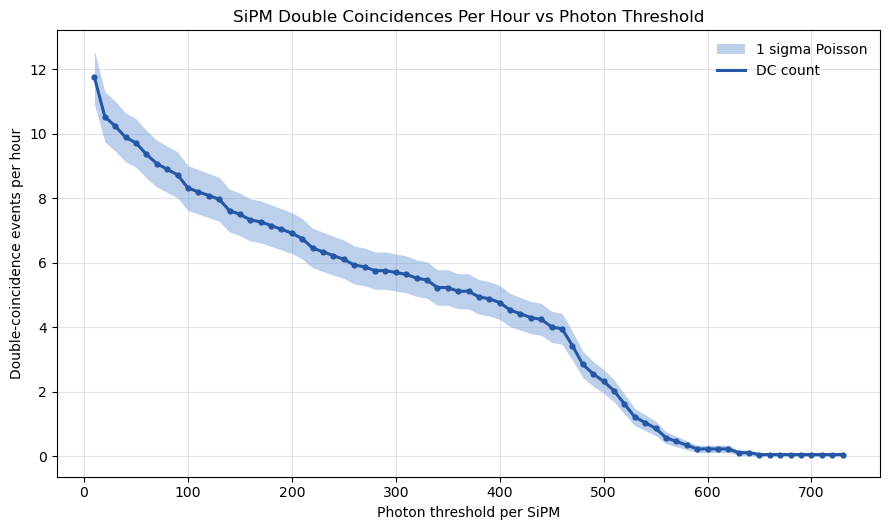

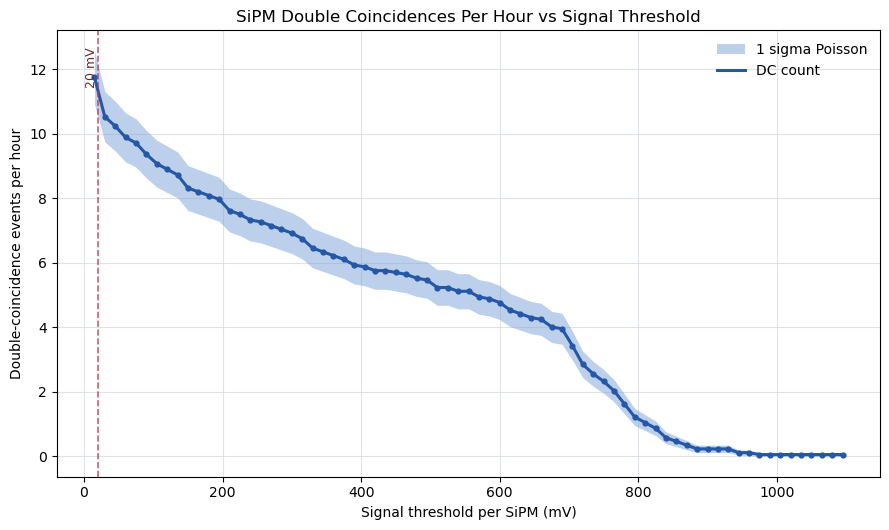

read events: 2788
thresholds scanned: 73
first threshold: 10
last threshold: 730
first count: 202
last count: 1
duration minutes: 1031.815
rate scale per hour: 0.05814995905273716
x-axis scale: 1.5
x-axis label: Signal threshold per SiPM (mV)
Voltage-threshold coincidence rates:
  20 mV: 195 events, 11.3392 events/hour (count threshold 13.3333 per SiPM)
photon scan CSV: /Users/matildalawton/cosmic-geant/analysis/dilution_detector/results/notebook_double_coincidence_threshold_scan_photons.csv
photon plot: /Users/matildalawton/cosmic-geant/analysis/dilution_detector/results/notebook_double_coincidence_threshold_scan_photons.png
voltage scan CSV: /Users/matildalawton/cosmic-geant/analysis/dilution_detector/results/notebook_double_coincidence_threshold_scan_voltage.csv
voltage plot: /Users/matildalawton/cosmic-geant/analysis/dilution_detector/results/notebook_double_coincidence_threshold_scan_voltage.png


In [9]:
counts = read_event_counts(COUNTS_CSV, COUNT_COLUMNS)
thresholds = build_thresholds(counts, THRESHOLD_START, THRESHOLD_STEP, MAX_THRESHOLD)
scan = scan_thresholds(counts, thresholds)
x_scale, x_label, converted_x_column = x_axis_scale(X_EFFICIENCY, MV_PER_DETECTED_PHOTON)

write_photon_threshold_scan(OUTPUT_PHOTON_SCAN_CSV, scan, DURATION_MINUTES)
fig_photon, ax_photon = plot_photon_threshold_scan(
    OUTPUT_PHOTON_PLOT,
    scan,
    DURATION_MINUTES,
    SIGMA_ALPHA,
)

write_voltage_threshold_scan(OUTPUT_VOLTAGE_SCAN_CSV, scan, DURATION_MINUTES, X_EFFICIENCY, MV_PER_DETECTED_PHOTON)
fig_voltage, ax_voltage = plot_voltage_threshold_scan(
    OUTPUT_VOLTAGE_PLOT,
    scan,
    VOLTAGE_MARK_THRESHOLDS_MV,
    DURATION_MINUTES,
    SIGMA_ALPHA,
    X_EFFICIENCY,
    MV_PER_DETECTED_PHOTON,
)
plt.show()

print(f"read events: {len(counts)}")
print(f"thresholds scanned: {len(thresholds)}")
print(f"first threshold: {thresholds[0]}")
print(f"last threshold: {thresholds[-1]}")
print(f"first count: {scan[0][1]}")
print(f"last count: {scan[-1][1]}")
if DURATION_MINUTES is not None:
    print(f"duration minutes: {DURATION_MINUTES}")
    print(f"rate scale per hour: {60.0 / DURATION_MINUTES}")
if x_scale != 1.0:
    print(f"x-axis scale: {x_scale}")
    print(f"x-axis label: {x_label}")
print_voltage_threshold_rates(
    counts,
    VOLTAGE_MARK_THRESHOLDS_MV,
    X_EFFICIENCY,
    MV_PER_DETECTED_PHOTON,
    DURATION_MINUTES,
)
print(f"photon scan CSV: {OUTPUT_PHOTON_SCAN_CSV}")
print(f"photon plot: {OUTPUT_PHOTON_PLOT}")
print(f"voltage scan CSV: {OUTPUT_VOLTAGE_SCAN_CSV}")
print(f"voltage plot: {OUTPUT_VOLTAGE_PLOT}")


# Scaling with muon attenuation

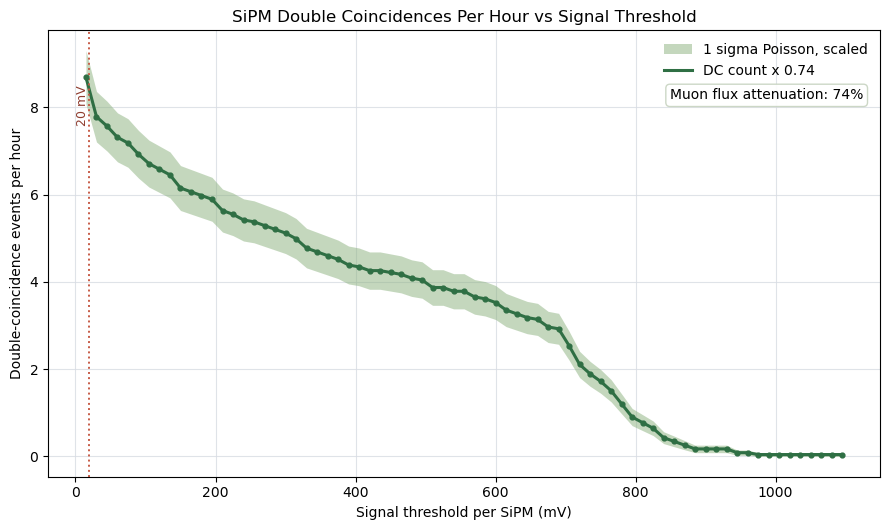

Muon-attenuated voltage-threshold coincidence rates:
  20 mV: 8.39104 attenuated events/hour (144.3 attenuated events, count threshold 13.3333 per SiPM)
attenuated voltage plot: /Users/matildalawton/cosmic-geant/analysis/dilution_detector/results/notebook_double_coincidence_threshold_scan_voltage_muon_attenuated.png


In [10]:
MUON_ATTENUATION_SCALE = 0.74
OUTPUT_ATTENUATED_VOLTAGE_PLOT = RESULTS_DIR / "notebook_double_coincidence_threshold_scan_voltage_muon_attenuated.png"

counts = read_event_counts(COUNTS_CSV, COUNT_COLUMNS)
thresholds = build_thresholds(counts, THRESHOLD_START, THRESHOLD_STEP, MAX_THRESHOLD)
scan = scan_thresholds(counts, thresholds)
x_scale, x_label, converted_x_column = x_axis_scale(X_EFFICIENCY, MV_PER_DETECTED_PHOTON)

x_values = [threshold * x_scale for threshold, _ in scan]
rate_scale = 60.0 / DURATION_MINUTES if DURATION_MINUTES is not None else 1.0
raw_coincidences = [coincidences for _, coincidences in scan]
attenuated_y = [coincidences * rate_scale * MUON_ATTENUATION_SCALE for coincidences in raw_coincidences]
attenuated_sigma = [(coincidences**0.5) * rate_scale * MUON_ATTENUATION_SCALE for coincidences in raw_coincidences]
attenuated_lower = [max(0.0, value - error) for value, error in zip(attenuated_y, attenuated_sigma)]
attenuated_upper = [value + error for value, error in zip(attenuated_y, attenuated_sigma)]

fig, ax = plt.subplots(figsize=(9, 5.4))
ax.fill_between(
    x_values,
    attenuated_lower,
    attenuated_upper,
    color="#8ab17d",
    alpha=SIGMA_ALPHA,
    linewidth=0,
    label="1 sigma Poisson, scaled",
)
ax.plot(x_values, attenuated_y, color="#2f6f44", linewidth=2.2, label="DC count x 0.74")
ax.scatter(x_values, attenuated_y, color="#2f6f44", s=12, zorder=3)

for marked_voltage in VOLTAGE_MARK_THRESHOLDS_MV:
    ax.axvline(marked_voltage, color="#c75c48", linestyle=":", linewidth=1.4)
    ax.text(
        marked_voltage,
        max(attenuated_y) * 0.98 if attenuated_y else 0,
        f"{marked_voltage:g} mV",
        color="#8f3d2f",
        rotation=90,
        va="top",
        ha="right",
        fontsize=9,
    )

title_suffix = " Per Hour" if DURATION_MINUTES is not None else ""
ax.set_title(f"SiPM Double Coincidences{title_suffix} vs Signal Threshold")
ax.set_xlabel(x_label)
ax.set_ylabel("Double-coincidence events per hour" if DURATION_MINUTES is not None else "Double-coincidence events")
ax.text(
    0.98,
    0.87,
    "Muon flux attenuation: 74%",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "#c7d3c0", "alpha": 0.9},
)
ax.grid(True, color="#d8dce3", linewidth=0.8, alpha=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig(OUTPUT_ATTENUATED_VOLTAGE_PLOT, dpi=180)
plt.show()

print("Muon-attenuated voltage-threshold coincidence rates:")
for voltage_threshold_mv in VOLTAGE_MARK_THRESHOLDS_MV:
    count_threshold = voltage_threshold_mv / x_scale
    double_coincidence_events = sum(
        1 for lower, upper in counts if lower >= count_threshold and upper >= count_threshold
    )
    attenuated_events = double_coincidence_events * MUON_ATTENUATION_SCALE
    if DURATION_MINUTES is None:
        print(
            f"  {voltage_threshold_mv:g} mV: {attenuated_events:.6g} attenuated events "
            f"(count threshold {count_threshold:.6g} per SiPM)"
        )
    else:
        attenuated_rate_per_hour = attenuated_events * 60.0 / DURATION_MINUTES
        print(
            f"  {voltage_threshold_mv:g} mV: {attenuated_rate_per_hour:.6g} attenuated events/hour "
            f"({attenuated_events:.6g} attenuated events, count threshold {count_threshold:.6g} per SiPM)"
        )

print(f"attenuated voltage plot: {OUTPUT_ATTENUATED_VOLTAGE_PLOT}")



# Individual SiPM count rates

In [11]:
#i want to read in this file:  /Users/matildalawton/cosmic-geant/analysis/dilution_detector/results/notebook_sipm_counts_by_event.csv 
# I then want to count individual sipm events -
# i want to plot the rates of each sipm vs threshold 
# i then want to extract the count rate for each sipm 
# then i want to calculate accidental coincidence 

COUNTS_CSV = COUNT_OUTPUT_CSV

# THRESHOLD_START = 10
# THRESHOLD_STEP = 10
# MAX_THRESHOLD = None

DURATION_MINUTES = duration_minutes
VOLTAGE_MARK_THRESHOLDS_MV = [20]
SIGMA_ALPHA = 0.5

# Use these for the voltage-scaled plot. Use 1.0 when counts are already PDE-weighted.
X_EFFICIENCY = 1.0
MV_PER_DETECTED_PHOTON = 1.5

#sipm 1 and sipm 2 events 
COUNT_COLUMNS = "sipm_copy_0_pde_weighted_detected_photons,sipm_copy_1_pde_weighted_detected_photons"

#counting total number of individual sipm events
#sipm1_total_counts  = number of rows in the csv where sipm_copy_0_pde_weighted_detected_photons > 0
#sipm2_total_counts  = number of rows in the csv where sipm_copy_1_pde_weighted_detected_photons > 0

sipm_counts = read_event_counts(COUNTS_CSV, COUNT_COLUMNS)
sipm1_total_counts = 0
sipm2_total_counts = 0
double_coincidences = 0
# for row in sipm_counts:
#     sipm1_count, sipm2_count = row
#     # You can now process each row to count individual SiPM events
#     if sipm1_count > 0:
#         # Increment your counter for SiPM 1
#         sipm1_total_counts += 1
#     if sipm2_count > 0:
#         # Increment your counter for SiPM 2
#         sipm2_total_counts += 1

#since we know 1.5 mV corresponds to 13.33 photons, we can set a minimum of 13.33 photons such that each of these events are above threshold

for row in sipm_counts:
    sipm1_count, sipm2_count = row
    if sipm1_count > 13.33:
        # Increment your counter for SiPM 1
        sipm1_total_counts += 1
    if sipm2_count > 13.33:
        # Increment your counter for SiPM 2
        sipm2_total_counts += 1
    if sipm1_count > 13.33 and sipm2_count > 13.33:
        # Increment your counter for double coincidences
        double_coincidences += 1

print(f"Total individual SiPM 1 events: {sipm1_total_counts}")
print(f"Total individual SiPM 2 events: {sipm2_total_counts}")
print(f"Total double coincidences: {double_coincidences}")


sipm1_rate_per_hour = sipm1_total_counts * 60.0 / DURATION_MINUTES
sipm2_rate_per_hour = sipm2_total_counts * 60.0 / DURATION_MINUTES
coincidence_rate = double_coincidences * 60.0 / DURATION_MINUTES

print(f"SiPM 1 rate: {sipm1_rate_per_hour:.6g} events per hour")
print(f"SiPM 2 rate: {sipm2_rate_per_hour:.6g} events per hour")
print(f"Double coincidence rate: {coincidence_rate:.6g} events per hour")

#sclaing with attenuation factor of 0.74 for muon flux
attenuation_factor = 0.74
sipm1_rate_per_hour_attenuated = sipm1_rate_per_hour * attenuation_factor
sipm2_rate_per_hour_attenuated = sipm2_rate_per_hour * attenuation_factor
coincidence_rate_attenuated = coincidence_rate * attenuation_factor

print(f"SiPM 1 rate (attenuated): {sipm1_rate_per_hour_attenuated:.6g} events per hour")
print(f"SiPM 2 rate (attenuated): {sipm2_rate_per_hour_attenuated:.6g} events per hour")
print(f"Double coincidence rate (attenuated): {coincidence_rate_attenuated:.6g} events per hour")

Total individual SiPM 1 events: 1271
Total individual SiPM 2 events: 1260
Total double coincidences: 195
SiPM 1 rate: 73.9086 events per hour
SiPM 2 rate: 73.2689 events per hour
Double coincidence rate: 11.3392 events per hour
SiPM 1 rate (attenuated): 54.6924 events per hour
SiPM 2 rate (attenuated): 54.219 events per hour
Double coincidence rate (attenuated): 8.39104 events per hour


# Processing Environmental Gamma Hits 

In [12]:

#lets look at gamma hits ot anything 

def count_gamma_hits(output_csv: Path,
    files: list[Path],
    background: bool,
) -> int:
    fieldnames = [
        "EventID",
        "volume",
        "energy_deposited",
    ]
    output_csv.parent.mkdir(parents=True, exist_ok=True)
    gamma_hits = 0
    
    if background:
        for path in files:
            for row in iter_hit_rows(path):
                event_id = parse_int_field(row, "EventID")
                particle = row.get("Particle", "")
                volume = row.get("Volume", "").lower()
                energy_deposited = parse_float_field(row, "EnergyDeposited")
                if particle == "gamma":
                    gamma_hits += 1
                    with output_csv.open("a", newline="") as handle:
                        writer = csv.DictWriter(handle, fieldnames=fieldnames)
                        writer.writerow(
                            {
                                "EventID": event_id,
                                "volume": volume,
                                "energy_deposited": f"{energy_deposited:.10g}",
                            }
                        )
                        
    return gamma_hits

def write_gamma_scintillator_hit_counts(
    output_csv: Path,
    files: list[Path],
    background: bool,
) -> int:
    fieldnames = [
        "EventID",
        "sipm_copy_0_photons",
        "sipm_copy_1_photons",
        "coincidence",
    ]
    output_csv.parent.mkdir(parents=True, exist_ok=True)

    sipm_counts: dict[int, list[float]] = defaultdict(lambda: [0.0, 0.0])
    gamma_scintillator_event_ids: list[int] = []


    if background:
        for path in files:
            for row in iter_hit_rows(path):
                event_id = parse_int_field(row, "EventID")
                particle = row.get("Particle", "")
                volume = row.get("Volume", "").lower()

                if particle == "opticalphoton" and "sipm" in volume:
                    copy_number = parse_int_field(row, "Copynumber")
                    if copy_number in (0, 1):
                        sipm_counts[event_id][copy_number] += 1.0

                if particle == "gamma" and "scintillator" in volume:
                    gamma_scintillator_event_ids.append(event_id)

    with output_csv.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        for event_id in gamma_scintillator_event_ids:
            counts = sipm_counts.get(event_id, [0.0, 0.0])
            writer.writerow(
                {
                    "EventID": event_id,
                    "sipm_copy_0_photons": f"{counts[0]:.10g}",
                    "sipm_copy_1_photons": f"{counts[1]:.10g}",
                    "coincidence": int(counts[0] > 0 and counts[1] > 0),
                }
            )

    return len(gamma_scintillator_event_ids)

gamma_hits = count_gamma_hits(
    GAMMA_OUTPUT_CSV,
    files,
    background,
)

gamma_scintillator_hits = write_gamma_scintillator_hit_counts(
    GAMMA_SCINTILLATOR_OUTPUT_CSV,
    files,
    background,
)

print(f"gamma hits output: {GAMMA_OUTPUT_CSV}")
print(f"gamma hits written: {gamma_hits}")
print(f"gamma scintillator hit rows written: {gamma_scintillator_hits}")
print(f"gamma scintillator output: {GAMMA_SCINTILLATOR_OUTPUT_CSV}")
if not background:
    print("background is False, so only the CSV header was written")


# i want to take the gamma csv -> count the number of coincidences, countthe number of inividual sipm events 
# I want to then conver thte counts into a rate
COUNT_COLUMNS = "sipm_copy_0_photons,sipm_copy_1_photons"
GAMMA_THRESHOLD_PHOTONS = 13.33

if not background:
    print("No gamma scintillator events found: background is False")
elif not GAMMA_SCINTILLATOR_OUTPUT_CSV.exists():
    print(f"No gamma scintillator events found: {GAMMA_SCINTILLATOR_OUTPUT_CSV} does not exist")
else:
    with GAMMA_SCINTILLATOR_OUTPUT_CSV.open(newline="") as handle:
        gamma_rows = list(csv.DictReader(handle))

    if not gamma_rows:
        print("No gamma scintillator events found")
    else:
        background_counts = read_event_counts(GAMMA_SCINTILLATOR_OUTPUT_CSV, COUNT_COLUMNS)

        sipm1_gamma_events = 0
        sipm2_gamma_events = 0
        double_coincidences_gamma = 0

        for row in background_counts:
            sipm1_count, sipm2_count = row
            if sipm1_count > GAMMA_THRESHOLD_PHOTONS:
                # Increment your counter for SiPM 1
                sipm1_gamma_events += 1
            if sipm2_count > GAMMA_THRESHOLD_PHOTONS:
                # Increment your counter for SiPM 2
                sipm2_gamma_events += 1
            if sipm1_count > GAMMA_THRESHOLD_PHOTONS and sipm2_count > GAMMA_THRESHOLD_PHOTONS:
                # Increment your counter for double coincidences
                double_coincidences_gamma += 1

        print(f"Total individual SiPM 1 events: {sipm1_gamma_events}")
        print(f"Total individual SiPM 2 events: {sipm2_gamma_events}")
        print(f"Total double coincidences: {double_coincidences_gamma}")

        sipm1_rate_per_hour_gamma = sipm1_gamma_events * 60.0 / DURATION_MINUTES
        sipm2_rate_per_hour_gamma = sipm2_gamma_events * 60.0 / DURATION_MINUTES
        coincidence_rate_gamma = double_coincidences_gamma * 60.0 / DURATION_MINUTES

        print(f"SiPM 1 rate: {sipm1_rate_per_hour_gamma:.6g} events per hour")
        print(f"SiPM 2 rate: {sipm2_rate_per_hour_gamma:.6g} events per hour")
        print(f"Double coincidence rate: {coincidence_rate_gamma:.6g} events per hour")


gamma hits output: /Users/matildalawton/cosmic-geant/analysis/dilution_detector/results/notebook_gamma_hits.csv
gamma hits written: 39847
gamma scintillator hit rows written: 0
gamma scintillator output: /Users/matildalawton/cosmic-geant/analysis/dilution_detector/results/notebook_gamma_scintillator_hits.csv
No gamma scintillator events found


## Handy Presets

Copy these into the settings cells above when you want the common raw, flat-efficiency, or PDE-weighted workflows.

In [13]:
# Raw photon count workflow
# RUN_INPUTS = ["runs/stage_fridge_clock_above_20cm_cry_10M_20260724_152447"]
# PDE_CSV = None
# MIN_PHOTONS_PER_SIPM = 1
# SIPM_EFFICIENCY = None
# MIN_DETECTED_PHOTONS_PER_SIPM = None
# COUNT_OUTPUT_CSV = RESULTS_DIR / "stage_fridge_10M_sipm_counts_by_event.csv"
# DOUBLE_EVENTS_OUTPUT_CSV = RESULTS_DIR / "stage_fridge_10M_double_events.csv"
# SUMMARY_JSON = RESULTS_DIR / "stage_fridge_10M_summary.json"

# Flat 40% efficiency, 80 detected photons threshold
# SIPM_EFFICIENCY = 0.40
# MIN_DETECTED_PHOTONS_PER_SIPM = 80

# PDE-weighted workflow
# PDE_CSV = ANALYSIS_DIR / "pde_digitization" / "sipm_pde_digitized.csv"
# PDE_COLUMN = "pde_5v_percent"
# COUNT_OUTPUT_CSV = RESULTS_DIR / "stage_fridge_10M_sipm_counts_by_event_pde5v.csv"
# COUNT_COLUMNS = "sipm_copy_0_pde_weighted_detected_photons,sipm_copy_1_pde_weighted_detected_photons"
# X_EFFICIENCY = 1.0
# MV_PER_DETECTED_PHOTON = 1.5
# DURATION_MINUTES = 700